<a href="https://colab.research.google.com/github/juanchomvasquez/soccer-world-cup-analysis/blob/main/01_world_cup_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FIFA World Cup: Historical Scoring Trends & Match Competitiveness (1930–2026)

## Project Overview

This project analyzes historical FIFA World Cup match results to identify changes in scoring patterns and investigate whether the expansion from 32 to 48 teams in 2026 coincided with changes in match competitiveness.

Using Python and pandas, the analysis explores historical scoring averages, goal differences, and the frequency of one-sided matches.

### Research Questions

1. How has the average number of goals per match evolved throughout World Cup history?
2. Did the 2026 World Cup have a higher proportion of one-sided matches than the 2022 tournament?
3. What do these findings suggest about the relationship between tournament expansion and match competitiveness?

### Tools & Technologies

- **Python:** Data analysis
- **pandas:** Data manipulation, filtering and aggregation
- **Matplotlib:** Data visualization
- **Google Colab:** Notebook development

### Dataset

**Source:** [International Football Results — Mart Jürisoo](https://github.com/martj42/international_results)

The dataset contains historical international football match results, including dates, participating teams, scores, tournaments and locations.

The analysis focuses exclusively on matches classified as FIFA World Cup fixtures.

## 1. Data Import & Exploration


In [25]:
import pandas as pd

# Dataset: International football match results

# Use a fixed version of the dataset
url = (
    "https://raw.githubusercontent.com/"
    "martj42/international_results/"
    "b7a3a8ee5d37780c6a03101c188658fd439e241d/"
    "results.csv"
)


# Read the CSV file into a DataFrame
df = pd.read_csv(url)

# Display the first five rows
df.head()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [26]:
print("Dataset dimensions:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset dimensions:
(49945, 9)

Column names:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


## 2. Data Preparation


In [27]:
# Filter only FIFA World Cup matches
world_cup = df[df["tournament"] == "FIFA World Cup"].copy()

# Count how many World Cup matches are in our dataset
print("Total World Cup matches:", len(world_cup))

# Preview our filtered data
world_cup.head()


Total World Cup matches: 1068


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1490,1930-07-13,Belgium,United States,0,3,FIFA World Cup,Montevideo,Uruguay,True
1491,1930-07-13,France,Mexico,4,1,FIFA World Cup,Montevideo,Uruguay,True
1492,1930-07-14,Brazil,Yugoslavia,1,2,FIFA World Cup,Montevideo,Uruguay,True
1493,1930-07-14,Peru,Romania,1,3,FIFA World Cup,Montevideo,Uruguay,True
1494,1930-07-15,Argentina,France,1,0,FIFA World Cup,Montevideo,Uruguay,True


## 3. Historical Scoring Analysis


In [28]:
# Calculate goals scored in each match
world_cup["total_goals"] = (
    world_cup["home_score"] + world_cup["away_score"]
)

# Calculate the average
average_goals = world_cup["total_goals"].mean()

print("Average goals per World Cup match:")
print(round(average_goals, 2))


Average goals per World Cup match:
2.84


In [29]:

# Convert the date column into a date format
world_cup["date"] = pd.to_datetime(world_cup["date"])

# Extract the year from each match date
world_cup["year"] = world_cup["date"].dt.year

# Group the data by World Cup year
goals_by_year = world_cup.groupby("year").agg(
    matches=("total_goals", "count"),
    total_goals=("total_goals", "sum"),
    avg_goals=("total_goals", "mean")
)

# Round the averages to two decimal places
goals_by_year["avg_goals"] = (
    goals_by_year["avg_goals"].round(2)
)

# Display the results
goals_by_year


,matches,total_goals,avg_goals
year,,,
1930,18,70,3.89
1934,17,70,4.12
1938,18,84,4.67
1950,22,88,4.00
1954,26,140,5.38
1958,35,126,3.60
1962,32,89,2.78
1966,32,89,2.78
1970,32,95,2.97


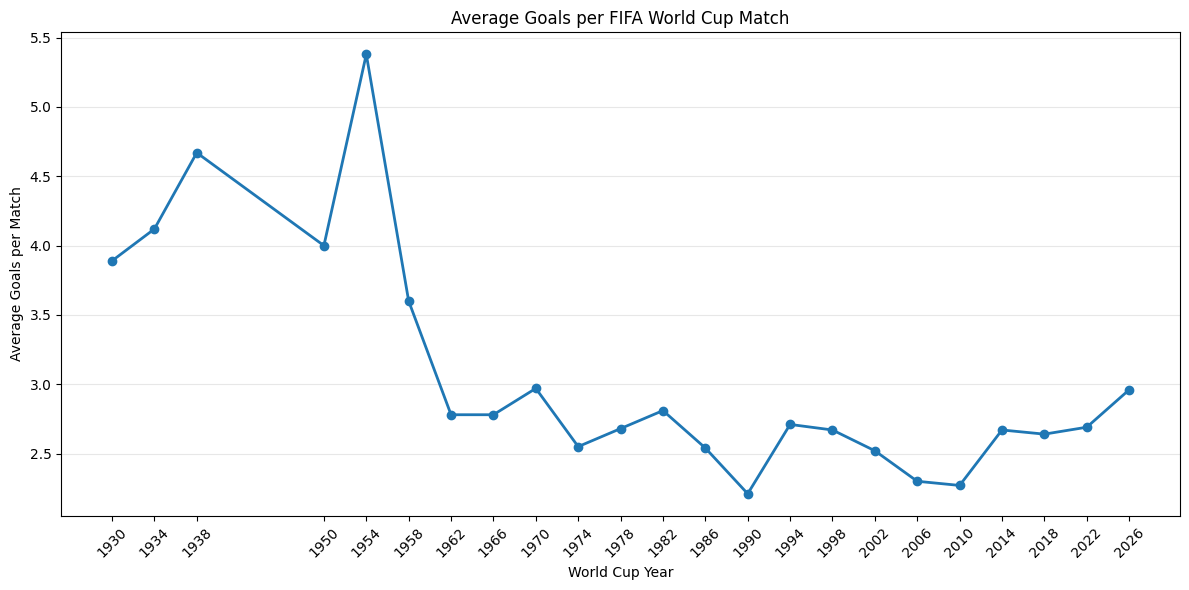

In [30]:

import matplotlib.pyplot as plt

# Create the chart
plt.figure(figsize=(12, 6))

# Plot average goals by tournament year
plt.plot(
    goals_by_year.index,
    goals_by_year["avg_goals"],
    marker="o",
    linewidth=2
)

# Chart title and labels
plt.title("Average Goals per FIFA World Cup Match")
plt.xlabel("World Cup Year")
plt.ylabel("Average Goals per Match")

# Show tournament years on the horizontal axis
plt.xticks(goals_by_year.index, rotation=45)

# Add horizontal gridlines
plt.grid(axis="y", alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()


### Analysis: Historical World Cup Scoring Trends

**Research question:** How has the average number of goals per World Cup match changed over time?

**Methodology:** Filtered international match results to FIFA World Cup matches, calculated total goals for each match, and aggregated results by tournament year using pandas.

**Findings:**
- Highest average: 1954, with 5.38 goals per match.
- Lowest average: 1990, with 2.21 goals per match.
- The 2026 tournament averaged 2.96 goals per match in the dataset.

**Limitation:** Scoring averages show changes in results but cannot independently establish the tactical causes. Historical coverage and data accuracy should also be verified against an authoritative source.

## 4. Data Quality Validation


In [31]:
# Check for missing values
print("Missing values by column:")
print(world_cup.isnull().sum())

# Check for duplicate matches
duplicates = world_cup.duplicated(
    subset=["date", "home_team", "away_team"]
).sum()

print("\nDuplicate matches:", duplicates)

# Check for invalid negative scores
negative_scores = (
    (world_cup["home_score"] < 0) |
    (world_cup["away_score"] < 0)
).sum()

print("Matches with negative scores:", negative_scores)

# Verify the number of matches by tournament
print("\nMatches per World Cup:")
print(world_cup.groupby("year").size())


Missing values by column:
date           0
home_team      0
away_team      0
home_score     0
away_score     0
tournament     0
city           0
country        0
neutral        0
total_goals    0
year           0
dtype: int64

Duplicate matches: 0
Matches with negative scores: 0

Matches per World Cup:
year
1930     18
1934     17
1938     18
1950     22
1954     26
1958     35
1962     32
1966     32
1970     32
1974     38
1978     38
1982     52
1986     52
1990     52
1994     52
1998     64
2002     64
2006     64
2010     64
2014     64
2018     64
2022     64
2026    104
dtype: int64


In [32]:

# Compare our results with official FIFA totals

print("Total World Cup matches:",
      len(world_cup))

print("Total World Cup goals:",
      world_cup["total_goals"].sum())

# Verify the 2026 tournament specifically
wc_2026 = world_cup[world_cup["year"] == 2026]

print("2026 matches:", len(wc_2026))

print("2026 total goals:",
      wc_2026["total_goals"].sum())


Total World Cup matches: 1068
Total World Cup goals: 3028
2026 matches: 104
2026 total goals: 308


### Validation Against Official FIFA Statistics

To assess dataset completeness and reliability, aggregate match and goal totals were compared with official FIFA World Cup statistics.

The dataset contains 1,068 World Cup matches and 3,028 goals between 1930 and 2026. For the 2026 tournament, the dataset records 104 matches and 308 goals.

All four figures match FIFA's published statistics.

**Validation result:** Aggregate match and goal totals were successfully reconciled with an independent authoritative source. However, individual match results were not independently verified, and additional record-level checks would be necessary to establish complete accuracy.

**Reference:** [FIFA — 2026 World Cup: On the Pitch](https://inside.fifa.com/tournament-organisation/fifa-world-cup-2026-by-the-numbers/on-the-pitch)

## 5. World Cup Expansion Analysis


In [33]:

# Select matches from 2022 and 2026
comparison = world_cup[
    world_cup["year"].isin([2022, 2026])
].copy()

# Calculate the absolute goal difference
comparison["goal_margin"] = (
    comparison["home_score"] -
    comparison["away_score"]
).abs()

# Identify matches decided by 3 or more goals
comparison["big_win"] = (
    comparison["goal_margin"] >= 3
)

# Display the first 10 matches
comparison[
    ["year", "home_team", "away_team",
     "goal_margin", "big_win"]
].head(10)


,year,home_team,away_team,goal_margin,big_win
45757,2022,Qatar,Ecuador,2,False
45758,2022,Senegal,Netherlands,2,False
45759,2022,England,Iran,4,True
45760,2022,United States,Wales,0,False
45761,2022,Argentina,Saudi Arabia,1,False
45762,2022,Mexico,Poland,0,False
45763,2022,Denmark,Tunisia,0,False
45764,2022,France,Australia,3,True
45765,2022,Germany,Japan,1,False
45766,2022,Spain,Costa Rica,7,True


In [34]:
# Summarize each tournament
comparison_summary = comparison.groupby("year").agg(
    matches=("goal_margin", "size"),
    avg_goals=("total_goals", "mean"),
    avg_margin=("goal_margin", "mean"),
    big_wins=("big_win", "sum"),
    big_win_rate=("big_win", "mean")
)

# Convert the proportion to a percentage
comparison_summary["big_win_rate"] *= 100

# Display the results
comparison_summary.round(2)


,matches,avg_goals,avg_margin,big_wins,big_win_rate
year,,,,,
2022,64,2.69,1.41,9,14.06
2026,104,2.96,1.56,22,21.15


### Analysis: World Cup Expansion and Match Competitiveness

The expansion of the FIFA World Cup from 32 to 48 teams coincided with an increase in one-sided matches.

According to the dataset, the proportion of matches decided by three or more goals increased from **14.06% in 2022 to 21.15% in 2026**, a rise of 7.09 percentage points.

However, the average absolute goal margin increased by only 0.15 goals, from 1.41 to 1.56. This suggests that the overall change in match competitiveness was less dramatic than the raw number of big wins might indicate.

These findings are consistent with the hypothesis that tournament expansion contributed to more mismatched games. However, the analysis does not establish causation, and further investigation into team strength and match outcomes is necessary.

In [35]:
# Categorize matches by goal difference
comparison["margin_category"] = pd.cut(
    comparison["goal_margin"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["Draw", "1-goal win",
            "2-goal win", "3+ goal win"]
)

# Calculate the percentage of matches in each category
margin_distribution = pd.crosstab(
    comparison["year"],
    comparison["margin_category"],
    normalize="index"
) * 100

# Round to two decimal places
margin_distribution.round(2)


margin_category,Draw,1-goal win,2-goal win,3+ goal win
year,,,,
2022,23.44,37.50,25.00,14.06
2026,23.08,33.65,22.12,21.15


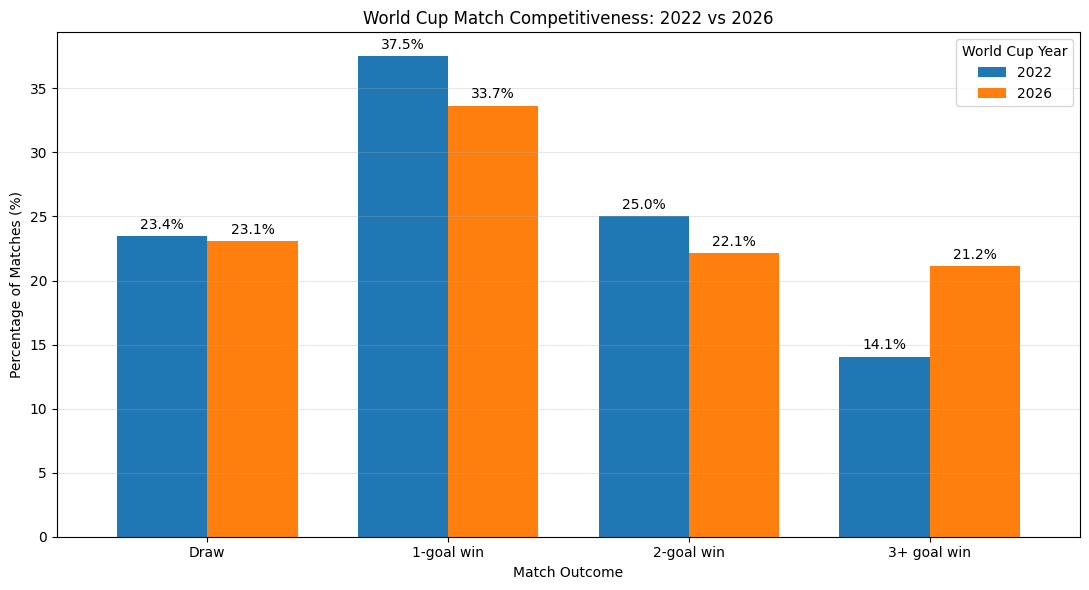

In [36]:

# Compare goal-margin distributions
ax = margin_distribution.T.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75
)

# Add chart title and labels
ax.set_title("World Cup Match Competitiveness: 2022 vs 2026")
ax.set_xlabel("Match Outcome")
ax.set_ylabel("Percentage of Matches (%)")

# Format chart
ax.set_xticklabels(
    margin_distribution.columns,
    rotation=0
)

ax.legend(title="World Cup Year")
ax.grid(axis="y", alpha=0.3)

# Add percentage labels above bars
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


## 6. Key Findings & Conclusion

### Conclusion: Did World Cup Expansion Affect Competitiveness?

The expansion of the FIFA World Cup from 32 to 48 teams appears to have coincided with an increase in one-sided matches, although the overall impact was less dramatic than the raw numbers might suggest. Matches decided by three or more goals increased from 14.06% in 2022 to 21.15% in 2026, while the average absolute goal margin rose only slightly, from 1.41 to 1.56 goals. Interestingly, the percentage of draws remained almost unchanged, suggesting that closely contested matches were still a significant part of the tournament. While these findings support the possibility that expansion contributed to greater differences in team competitiveness, further analysis of team rankings, opponent strength, and tournament stages would be necessary to determine whether expansion was responsible.